### MODELO RANDOM FOREST con eda5


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# To save models
import json
import pickle

# Modelado
from sklearn.ensemble import RandomForestClassifier

# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest

# Métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score
from sklearn.metrics import recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve

# Optimizar
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# from tqdm import tqdm
import warnings
import zipfile
import os

from utils import get_classifier_metrics


In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

In [3]:
# Lectura directa desde los archivos
X_train = pd.read_csv('../data/processed/X_train_eda7_obj1.csv')
X_test = pd.read_csv('../data/processed/X_test_eda7_obj1.csv')
y_train = pd.read_csv('../data/processed/y_train_eda7_obj1.csv')
y_test = pd.read_csv('../data/processed/y_test_eda7_obj1.csv')

# Tip: Si el CSV tiene un nombre distinto dentro del zip, 
# pandas suele detectarlo automáticamente si solo hay uno.

In [ ]:
# Eliminar columna de índice sobrante si existe.
for df_temp in [X_train, X_test]:
    if 'Unnamed: 0' in df_temp.columns:
        df_temp.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
# Reviso que no haya valores nulos con la nueva carga de archivo.

# Lista de tus variables cargadas
datasets = {'X_train': X_train,'X_test': X_test,'y_train': y_train, 'y_test': y_test}

for nombre, df_actual in datasets.items():
    if df_actual is not None:
        total_nulos = df_actual.isnull().sum().sum() # Suma total de nulos en todo el dataframe
        print(f'{nombre}: {total_nulos} nulos encontrados.')
        
        # Si hay nulos, mostramos en qué columnas están
        if total_nulos > 0:
            df_actual.isnull().sum()[df_actual.isnull().sum() > 0]
            
    else:
        f'{nombre}: No está cargado (es None).'

X_train: 0 nulos encontrados.
X_test: 0 nulos encontrados.
y_train: 0 nulos encontrados.
y_test: 0 nulos encontrados.


## Entrenamiento del modelo.

In [ ]:
# Definimos RANGOS, no valores fijos
# Esto le da libertad total al modelo para explorar
param_dist = {'n_estimators': randint(100, 500),         # Que busque cualquier número entre 100 y 500
              'max_depth': [None, 10, 20, 30, 40, 50],   # Rangos amplios o profundidad ilimitada
              'min_samples_leaf': randint(50, 300),      # Para evitar overfitting en bolsa
              'max_features': ['sqrt', 'log2', None],     # Diferentes formas de elegir variables
              'bootstrap': [True]}

# Usamos RandomizedSearchCV
# n_iter=20 significa que probará 20 combinaciones aleatorias diferentes

tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=18, class_weight='balanced'),
                                   param_distributions=param_dist,
                                   n_iter=20, 
                                   cv=tscv,
                                   scoring='roc_auc',
                                   n_jobs=-1,
                                   verbose=1,
                                   random_state=18)

# Entrenar
random_search.fit(X_train, y_train)

# Resultado
best_rf = random_search.best_estimator_
f'Mejor configuración descubierta:', random_search.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mejor configuración descubierta: {'bootstrap': True, 'max_depth': 50, 'max_features': None, 'min_samples_leaf': 120, 'n_estimators': 441}


In [ ]:
# Predicciones con el mejor modelo
y_pred = best_rf.predict(X_test)

classification_report(y_test, y_pred)

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.48      0.49      0.48     59054
           1       0.53      0.51      0.52     64965

    accuracy                           0.50    124019
   macro avg       0.50      0.50      0.50    124019
weighted avg       0.50      0.50      0.50    124019



In [12]:
# Make predictions on the test set
y_pred= best_rf.predict(X_test)
y_prob= best_rf.predict_proba(X_test)[:, 1]

In [13]:
# Evaluate accuracy and other metrics
model_accuracy= accuracy_score(y_test, y_pred)
model_precision= precision_score(y_test, y_pred)
model_recall= recall_score(y_test, y_pred)
model_f1= f1_score(y_test, y_pred)
model_roc_auc= roc_auc_score(y_test, y_prob)
cm= confusion_matrix(y_test, y_pred)

In [10]:
# Showing results
model_accuracy, model_precision, model_recall, model_f1, model_roc_auc

(0.5032777235746135,
 0.5264616062714479,
 0.5148002770722697,
 0.520565642729841,
 0.5025335557497684)

Top 15 variables más importantes:
  Variable  Importancia
4   Volume     0.276771
3    Close     0.185908
0     Open     0.184872
2      Low     0.178407
1     High     0.174041


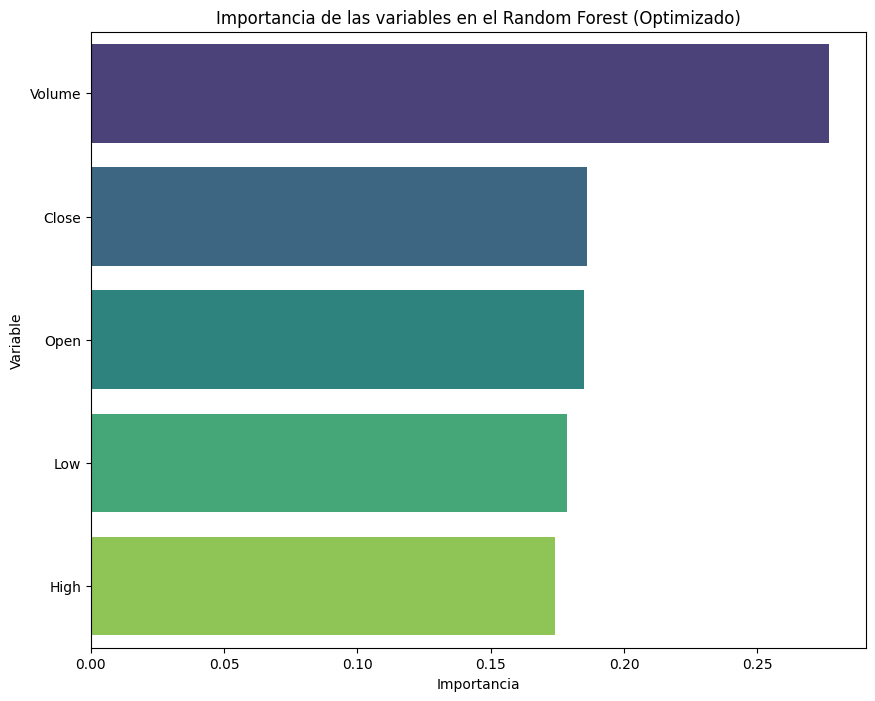

In [ ]:
# Extraer importancia de las variables del mejor modelo
importancias = pd.DataFrame({'Variable': X_train.columns,
                             'Importancia': best_rf.feature_importances_}).sort_values(by='Importancia', ascending=False)

# Top 15 variables más importantes:
importancias.head(15)

In [ ]:
# Graficar las 15 primeras para tener una mejor visión
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=importancias.head(15), palette='viridis')
plt.title('Importancia de las variables en el Random Forest (Optimizado)')
plt.show()